# The Safety-Net 🛑
### "Always use a stop-loss" — does cutting your losses at X% really protect (and pay)?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Cuts drawdown?: Mixed](https://img.shields.io/badge/Cuts_drawdown%3F-Mixed-dab617?style=flat-square)

The most-repeated rule in retail trading: *cut your losses, let your winners run* — set a **trailing stop** that sells when price falls X% from its peak. We take it literally on SPY, sweep the threshold (5 / 10 / 15 / 20%), and ask the two questions that matter: does it **cut the drawdown** (sometimes — it depends entirely on X), and does it **make you more money than just holding** (no).

> 📓 **This is the plain-language layer.** The statistics, the matched-coin control and the trending-vs-mean-reverting theory are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** Educational, reproducible research — every chart below is generated by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study root (safety_net/)
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from safety_net import data, strategy

AS_OF = "2026-06-12"
COOLDOWN, COST = 21, 5.0
STOPS = (5.0, 10.0, 15.0, 20.0)
frame = data.load_real("SPY", mode="total_return").loc[:AS_OF]
close = frame["close"]
bh = strategy.buy_and_hold(close)
runs = {x: strategy.backtest(close, strategy.trailing_stop_position(close, x, COOLDOWN), cost_bps=COST) for x in STOPS}
stop10 = runs[10.0]
print(f"SPY total return: {len(close):,} rows  {close.index[0].date()} -> {close.index[-1].date()}  fingerprint={data.fingerprint(frame)}")
print(f"B&H        Sharpe {bh['sharpe']:.3f}  maxDD {bh['max_dd']*100:.1f}%  CAGR {bh['cagr']*100:.2f}%")
print(f"stop 10%   Sharpe {stop10['sharpe']:.3f}  maxDD {stop10['max_dd']*100:.1f}%  CAGR {stop10['cagr']*100:.2f}%  TiM {stop10['time_in_market']*100:.0f}%")


SPY total return: 8,400 rows  1993-01-29 -> 2026-06-12  fingerprint=d74f157c34ef
B&H        Sharpe 0.646  maxDD -55.2%  CAGR 10.82%
stop 10%   Sharpe 0.752  maxDD -43.9%  CAGR 10.80%  TiM 92%


## The answer first 🎯

| Question | Answer |
|---|---|
| Does a stop-loss cut the big drawdown? | **Only at the right width.** A **10%** stop trims the worst drop to **-43.9%** from **-55.2%** (an **11-point** cut) — but a **20%** stop cuts almost nothing and a **5%** stop whipsaws. |
| Does it make you more money than holding? | **No.** The best width *matches* buy-and-hold (**10.8%/yr** vs **10.82%/yr**); a tight 5% stop **loses 4.8 points/yr**. |
| So what *is* a stop-loss? | Insurance you pay for in foregone upside — risk control that works in a narrow band, never a money machine. |

## 1 · The claim

*"Always use a stop-loss. Cut your losses and let your winners run. A trailing stop — exit when price falls X% from its peak — protects your capital, limits your drawdown, and improves your returns."* You'll find it in every broker tutorial and trading book.

## 2 · So what?

If a mechanical stop *both* lowered risk *and* raised return, it would be a free lunch every investor should take. That's a strong claim — so it deserves a fair, literal test across several thresholds rather than one flattering chart of 2008.

## 3 · How would we even know?

We hold SPY (dividends included), track its running peak, and **sell to cash the day it falls X% below that peak**; we wait a **21-day cooldown**, then buy back and reset the peak. We act **one day after** the trigger (no peeking) and pay **5 bps** per switch. Then we line each X up against two yardsticks: **buy-and-hold**, and a **random coin** that's out of the market for the *same total time, in similar-length stretches*, but on random dates. If the stop is just *"be in cash sometimes"*, it won't beat the coin.

## 4 · The teardown — let's actually look

First, the X-sweep: return, risk, and the drawdown each width really cuts.

In [2]:
tbl = pd.DataFrame({
  'CAGR %':  [bh['cagr']*100] + [runs[x]['cagr']*100 for x in STOPS],
  'Vol %':   [bh['vol']*100]  + [runs[x]['vol']*100 for x in STOPS],
  'Sharpe':  [bh['sharpe']]   + [runs[x]['sharpe'] for x in STOPS],
  'MaxDD %': [bh['max_dd']*100]+ [runs[x]['max_dd']*100 for x in STOPS],
  'TiM %':   [bh['time_in_market']*100] + [runs[x]['time_in_market']*100 for x in STOPS],
  'Switches':[bh['switches']] + [runs[x]['switches'] for x in STOPS],
}, index=['Buy & hold'] + [f'Stop {int(x)}%' for x in STOPS])
tbl.round(2)

,CAGR %,Vol %,Sharpe,MaxDD %,TiM %,Switches
Buy & hold,10.820,18.580,0.650,-55.190,100.000,0
Stop 5%,6.050,12.600,0.530,-48.040,75.740,195
Stop 10%,10.800,15.180,0.750,-43.880,92.240,63
Stop 15%,10.850,16.150,0.720,-46.690,95.740,35
Stop 20%,10.050,16.940,0.650,-54.730,97.740,19


Now the equity curves and drawdowns — the **10% stop** (its best width) against buy-and-hold.

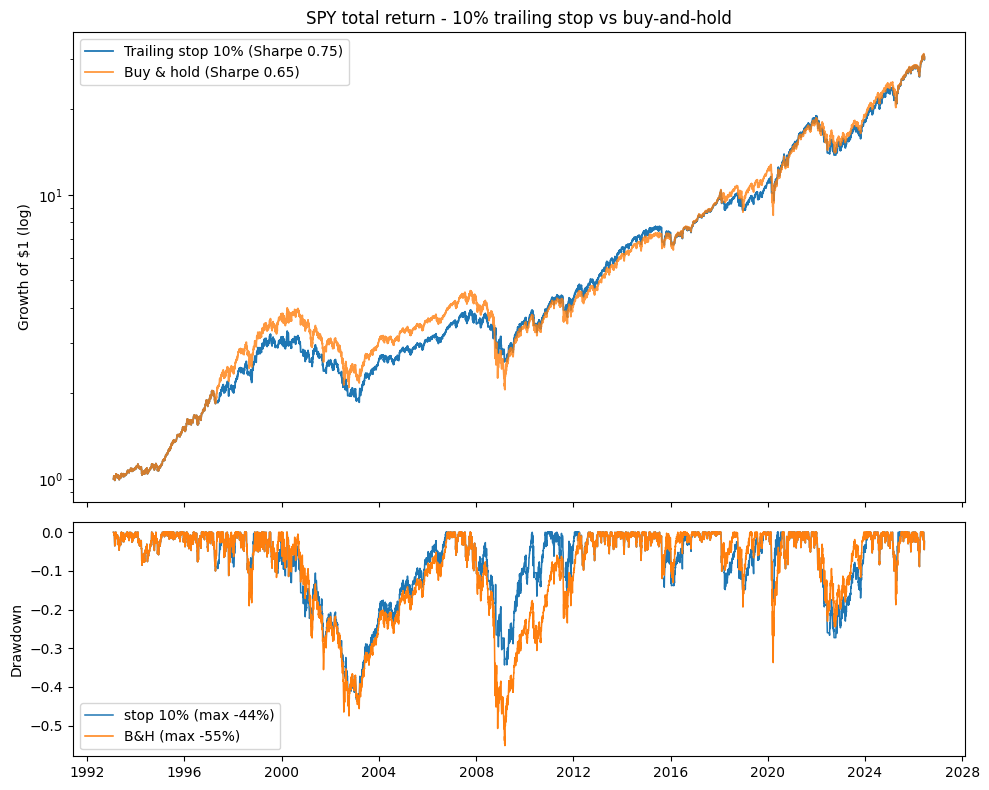

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, height_ratios=[2, 1])
ax1.plot(stop10['equity'], label=f"Trailing stop 10% (Sharpe {stop10['sharpe']:.2f})", lw=1.3)
ax1.plot(bh['equity'], label=f"Buy & hold (Sharpe {bh['sharpe']:.2f})", lw=1.3, alpha=.8)
ax1.set_yscale('log'); ax1.set_ylabel('Growth of $1 (log)'); ax1.legend(); ax1.set_title('SPY total return - 10% trailing stop vs buy-and-hold')
for d, lab in [(stop10, 'stop 10%'), (bh, 'B&H')]:
    eq = d['equity']; dd = eq/eq.cummax()-1
    ax2.plot(dd, label=f"{lab} (max {dd.min()*100:.0f}%)", lw=1.1)
ax2.set_ylabel('Drawdown'); ax2.legend(); ax2.set_xlabel('')
plt.tight_layout(); plt.show()

The stop's drawdown is shallower — it ducks part of 2008 — but the two curves **end at essentially the same place**. You bought a calmer ride; you did not buy more money.

Now the **matched random coin** at each X — is the stop's *timing* better than random in/out of the same amount?

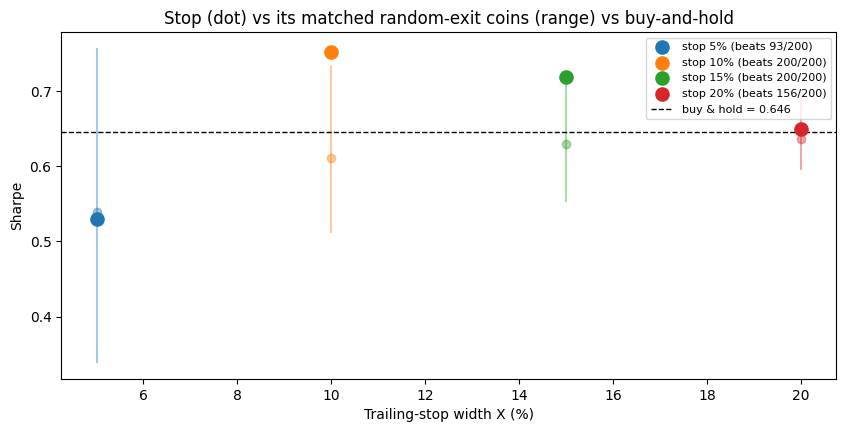

In [4]:
fig, ax = plt.subplots(figsize=(10,4.5))
colors = ['C0','C1','C2','C3']
for x, c in zip(STOPS, colors):
    pos = strategy.trailing_stop_position(close, x, COOLDOWN)
    rand = np.array([strategy.backtest(close, strategy.matched_random_position(pos, seed=s), cost_bps=COST)['sharpe'] for s in range(200)])
    beats = int((runs[x]['sharpe']>rand).sum())
    ax.scatter([x], [runs[x]['sharpe']], color=c, s=90, zorder=3, label=f'stop {int(x)}% (beats {beats}/200)')
    ax.errorbar([x], [rand.mean()], yerr=[[rand.mean()-rand.min()],[rand.max()-rand.mean()]], fmt='o', color=c, alpha=.4)
ax.axhline(bh['sharpe'], color='k', ls='--', lw=1, label=f"buy & hold = {bh['sharpe']:.3f}")
ax.set_xlabel('Trailing-stop width X (%)'); ax.set_ylabel('Sharpe'); ax.legend(fontsize=8)
ax.set_title('Stop (dot) vs its matched random-exit coins (range) vs buy-and-hold'); plt.show()

At **10% and 15%** the stop beats its random coin **200/200** times — the exit *dates* carry information. But the tight **5%** stop loses to random (**93/200**) — too jumpy, it fires on noise. And **not one width** beats buy-and-hold on return.

## 5 · The verdict

- **Cuts drawdown? → Mixed.** A 10% stop cuts **11 points** of drawdown; a 20% stop cuts **0**; a 5% stop cuts some but **bleeds 4.8 pts/yr** doing it. Protection is real only in a middle band.
- **Signal → Weak.** No width out-earns the market: the best (15%) is **+0.03 pts/yr** (a rounding error), 10% *matches* it. The Sharpe gain is lower exposure, not skill.
- **Improves returns? → Mirage.** As a way to *make more money*, the stop-loss doesn't — at best it trades return for a smoother ride you could buy more cheaply by just holding less stock.

## 6 · Could you actually trade it?

You can — it's just SPY, infinitely liquid. The problem isn't capacity: it's that the product is *less return (or equal) for less risk*, with the catch that **picking the wrong width hurts** (5% whipsaws away nearly half your return). Add the **taxes** on dozens of switches and the case for *"a stop-loss that improves returns"* collapses to a mirage.

## 7 · Going further 🚪

- Does earning the **T-bill** in cash (instead of 0%) close the gap? (It helps, but it's still de-risking, not alpha.)
- A **volatility-scaled** stop (X in units of recent vol) instead of a fixed %.
- The theory says stops *help trending assets*: try the same engine on a trend-following CTA tape or a single momentum name. Fork it and test the Kaminski-Lo split yourself.